# CardioIA — Ir Além 2: IA em séries temporais de saúde

Comparação entre **Regressão Logística** (baseline clássico) e uma **Spiking Neural Network (SNN) com neurônios LIF** implementada em TensorFlow puro, aplicada à classificação de batimentos cardíacos do **MIT-BIH Arrhythmia Database**.

## Como rodar no Colab

1. `Runtime` → `Change runtime type` → selecione **GPU** (acelera muito a SNN).
2. `Runtime` → `Run all`.

O notebook tenta baixar o MIT-BIH via PhysioNet. Se falhar (raro), cai automaticamente em ECG simulado via NeuroKit2, mantendo todo o pipeline funcional.

## Pipeline

```
ECG bruto → bandpass + normalização → segmentação em batidas (180 amostras / R-peak)
        → [A] features (estatísticas + FFT) → LogisticRegression
        → [B] entrada temporal direta → SNN (LIF → LIF) com surrogate gradient
        → métricas + spike raster + matriz de confusão
```


In [1]:
# Instalação de dependências não-padrão no Colab
!pip install -q wfdb neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 119.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal as sps
from scipy.stats import skew, kurtosis

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Reprodutibilidade
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU disponível:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.20.0
GPU disponível: True


## 1. Carregamento dos dados (MIT-BIH com fallback simulado)

O MIT-BIH Arrhythmia Database é o dataset clássico de ECG anotado batida-a-batida. Cada batimento tem um símbolo: `N` (normal), `V` (ventricular ectópico), `S` (supraventricular), etc. Vamos agrupar em **binário: Normal vs Anormal**, seguindo o padrão AAMI.

In [3]:
import wfdb
import neurokit2 as nk

DATA_DIR = './mitdb'
# Mistura de registros: 100/101/103 (mais batidas normais), 208/210 (mais ectópicas)
RECORDS = ['100', '101', '103', '208', '210']

def load_mit_bih():
    os.makedirs(DATA_DIR, exist_ok=True)
    sigs, anns, fs = [], [], None
    for rec in RECORDS:
        try:
            wfdb.dl_database('mitdb', dl_dir=DATA_DIR, records=[rec])
            sig, fields = wfdb.rdsamp(f'{DATA_DIR}/{rec}')
            ann = wfdb.rdann(f'{DATA_DIR}/{rec}', 'atr')
            sigs.append(sig[:, 0])  # canal MLII
            anns.append((ann.sample, ann.symbol))
            fs = fields['fs']
        except Exception as e:
            print(f'Falha em {rec}: {e}')
    if not sigs:
        raise RuntimeError('Nenhum registro baixado')
    return sigs, anns, fs

try:
    signals, annotations, FS = load_mit_bih()
    SOURCE = 'MIT-BIH'
except Exception as e:
    print(f'\n[Fallback] Usando ECG simulado: {e}')
    FS = 360
    s_norm = nk.ecg_simulate(duration=200, sampling_rate=FS, heart_rate=72,
                             noise=0.05, random_state=SEED)
    s_tach = nk.ecg_simulate(duration=200, sampling_rate=FS, heart_rate=150,
                             noise=0.10, random_state=SEED+1)
    signals = [s_norm, s_tach]
    annotations = None
    SOURCE = 'Simulado (NeuroKit2)'

print(f'\nFonte: {SOURCE} | Fs = {FS} Hz | sinais carregados: {len(signals)}')

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
Generating record list for: 208
Generating list of all files for: 208
Finished downloading files
Generating record list for: 210
Generating list of all files for: 210
Finished downloading files

Fonte: MIT-BIH | Fs = 360 Hz | sinais carregados: 5


## 2. Pré-processamento e segmentação em batidas

- **Bandpass 0.5–40 Hz** elimina baseline wander e ruído de alta frequência.
- **Normalização z-score** por registro estabiliza a escala entre pacientes.
- **Janela de 180 amostras** (~0.5s @ 360Hz) centrada no R-peak captura QRS + parte de T.

In [4]:
BEAT_WINDOW = 180
HALF_W = BEAT_WINDOW // 2

# Classificação AAMI agrupada (binária)
NORMAL_SYMBOLS   = {'N', 'L', 'R', 'e', 'j'}
ABNORMAL_SYMBOLS = {'A', 'a', 'J', 'S', 'V', 'F', '/', 'f', 'Q', 'E'}

def bandpass(sig, fs, low=0.5, high=40.0, order=4):
    sos = sps.butter(order, [low, high], btype='band', fs=fs, output='sos')
    return sps.sosfiltfilt(sos, sig)

def znorm(x):
    return (x - x.mean()) / (x.std() + 1e-8)

def segment_mitbih(signals, annotations, fs):
    X, y = [], []
    for sig, (samples, symbols) in zip(signals, annotations):
        s_clean = znorm(bandpass(sig, fs))
        for s, sym in zip(samples, symbols):
            if sym in NORMAL_SYMBOLS:
                lbl = 0
            elif sym in ABNORMAL_SYMBOLS:
                lbl = 1
            else:
                continue  # ignora marcadores não-batida ('+', '~', etc.)
            if s - HALF_W < 0 or s + HALF_W >= len(s_clean):
                continue
            X.append(s_clean[s - HALF_W : s + HALF_W])
            y.append(lbl)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

def segment_simulated(signals, fs):
    X, y = [], []
    for lbl, sig in enumerate(signals):
        s_clean = znorm(bandpass(sig, fs))
        _, info = nk.ecg_peaks(s_clean, sampling_rate=fs)
        peaks = info['ECG_R_Peaks']
        for s in peaks:
            if s - HALF_W < 0 or s + HALF_W >= len(s_clean):
                continue
            X.append(s_clean[s - HALF_W : s + HALF_W])
            y.append(lbl)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

if SOURCE == 'MIT-BIH':
    X, y = segment_mitbih(signals, annotations, FS)
else:
    X, y = segment_simulated(signals, FS)

print(f'Total de batidas: {len(X)}')
print(f'  Normal  (0): {(y == 0).sum()}')
print(f'  Anormal (1): {(y == 1).sum()}')
print(f'Shape X: {X.shape}')

Total de batidas: 11820
  Normal  (0): 10184
  Anormal (1): 1636
Shape X: (11820, 180)


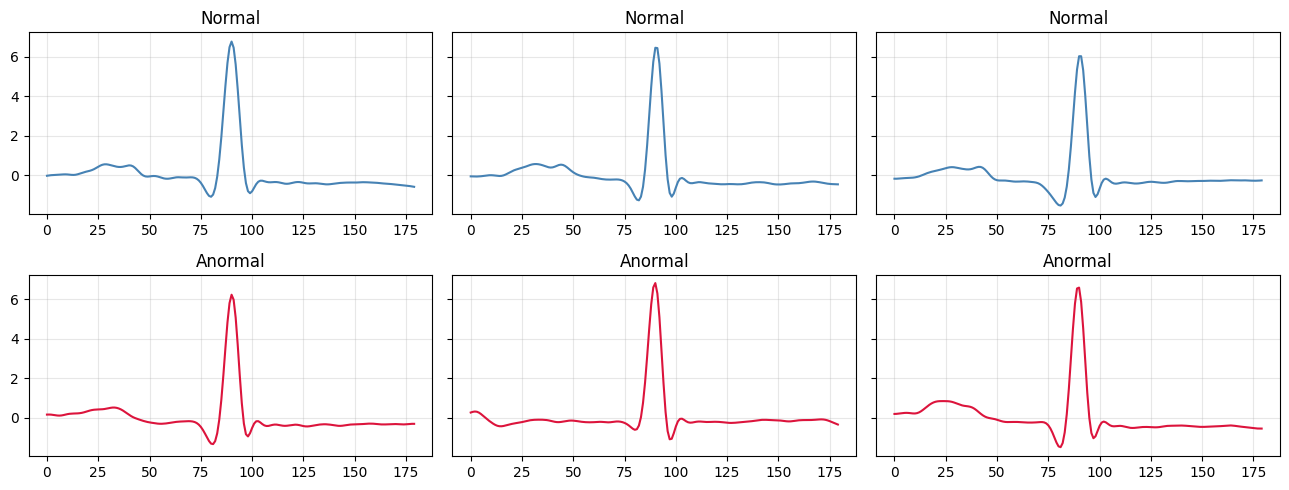

In [5]:
# Visualização: 3 batidas Normal vs 3 Anormal
fig, axes = plt.subplots(2, 3, figsize=(13, 5), sharey=True)
idx_n = np.where(y == 0)[0][:3]
idx_a = np.where(y == 1)[0][:3]
for ax, i in zip(axes[0], idx_n):
    ax.plot(X[i], color='steelblue'); ax.set_title('Normal'); ax.grid(alpha=.3)
for ax, i in zip(axes[1], idx_a):
    ax.plot(X[i], color='crimson'); ax.set_title('Anormal'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [6]:
# Split estratificado treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (9456, 180) | Teste: (2364, 180)


## 3. Caminho A — Regressão Logística com features extraídas

Features clássicas em análise de ECG:
- **Estatísticas temporais**: média, desvio, skew, kurtosis, min, max
- **Energia espectral** em 4 bandas via FFT (capta morfologia frequencial)
- **Gradiente**: média e máximo de |dx/dt| (capta agudez do QRS)

A regressão logística é linear nessas features — baseline forte, interpretável, treino instantâneo.

In [7]:
def extract_features(X):
    feats = []
    for beat in X:
        f = [
            beat.mean(), beat.std(), beat.min(), beat.max(),
            float(skew(beat)), float(kurtosis(beat)),
        ]
        # Energia em 4 bandas via FFT
        spec = np.abs(np.fft.rfft(beat)) ** 2
        bands = np.array_split(spec, 4)
        f += [float(b.sum()) for b in bands]
        # Gradiente
        d = np.diff(beat)
        f += [float(np.mean(np.abs(d))), float(np.max(np.abs(d)))]
        feats.append(f)
    return np.array(feats, dtype=np.float32)

F_train = extract_features(X_train)
F_test  = extract_features(X_test)

scaler = StandardScaler().fit(F_train)
F_train_s = scaler.transform(F_train)
F_test_s  = scaler.transform(F_test)

print(f'Features por batida: {F_train.shape[1]}')

lr = LogisticRegression(max_iter=2000, class_weight='balanced',
                        random_state=SEED).fit(F_train_s, y_train)

y_pred_lr = lr.predict(F_test_s)
y_prob_lr = lr.predict_proba(F_test_s)[:, 1]

print('\n=== Regressão Logística ===')
print(classification_report(y_test, y_pred_lr,
                            target_names=['Normal', 'Anormal']))

Features por batida: 12

=== Regressão Logística ===
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      2037
     Anormal       0.93      0.85      0.89       327

    accuracy                           0.97      2364
   macro avg       0.95      0.92      0.93      2364
weighted avg       0.97      0.97      0.97      2364



## 4. Caminho B — Spiking Neural Network (LIF) em TensorFlow

### Modelo LIF (Leaky Integrate-and-Fire)

Dinâmica discreta em cada timestep $t$:

$$V_{t+1} = \beta_i \cdot V_t + W \cdot x_t + b$$

$$s_t = \begin{cases} 1 & \text{se } V_{t+1} > \theta \\ 0 & \text{caso contrário} \end{cases}$$

$$V_{t+1} \leftarrow V_{t+1} - \theta \cdot s_t \quad \text{(soft reset após spike)}$$

O **soft reset** subtrai o limiar $\theta$ da membrana ao disparar, em vez de zerá-la completamente. Isso preserva o gradiente no backpropagation through time (BPTT): a carga acumulada antes do spike continua influenciando timesteps futuros.

O decaimento $\beta_i$ é **aprendível por neurônio** via sigmoid (Parametric LIF / PLIF):

$$\beta_i = \sigma(\text{beta\_raw}_i), \quad \beta_i \in (0, 1)$$

Cada neurônio adapta sua própria constante de tempo de membrana durante o treinamento.

### Surrogate gradient

A função spike (Heaviside) tem derivada zero quase em todo lugar — impossível treinar com backprop direto. Substituímos a derivada por uma **fast-sigmoid escalada** (sharpness = 5):

$$\frac{\partial s}{\partial V} \approx \frac{5}{(1 + 5\,|V - \theta|)^2}$$

O fator 5 concentra o gradiente próximo ao limiar, tornando o aprendizado mais eficiente. Isso é a base de toda SNN treinada modernamente (Neftci et al. 2019, Zenke & Vogels 2021).

In [8]:
@tf.custom_gradient
def spike_fn(x):
    """Heaviside com gradiente surrogate fast-sigmoid escalado (sharpness=5).
    Forward : 1 se x > 0, senao 0.
    Backward: 5 / (1 + 5|x|)^2  — foco maior perto do threshold, gradiente
    mais limpo do que a versao original sem escala.
    """
    out = tf.cast(tf.greater(x, 0.0), tf.float32)
    def grad(upstream):
        scale = 5.0
        return upstream * (scale / tf.square(1.0 + scale * tf.abs(x)))
    return out, grad


class LIFDense(layers.Layer):
    """Camada LIF totalmente conectada — versao melhorada (PLIF + soft reset).

    Melhorias vs versao original:
    * Bias adicionado (transformacao linear completa).
    * Soft reset: V <- V - threshold * s  (mantem gradiente no BPTT).
    * Beta aprendivel por neuronio via sigmoid (Parametric LIF / PLIF).
    * Surrogate gradient escalado para convergencia mais rapida.

    Entrada: (batch, T, in_features)
    Saida:   trem de spikes (batch, T, units)
    """

    def __init__(self, units, beta=0.9, threshold=1.0, learn_beta=True, **kwargs):
        super().__init__(**kwargs)
        self.units     = units
        self.beta      = beta
        self.threshold = threshold
        self.learn_beta = learn_beta

    def build(self, input_shape):
        self.W = self.add_weight(
            name='W',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
        )
        # bias — ausente na versao original, limitava muito a capacidade
        self.b = self.add_weight(
            name='b',
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
        )
        if self.learn_beta:
            # inicializa no espaco logit: sigmoid(logit) == beta inicial
            init_logit = float(np.log(self.beta / (1.0 - self.beta + 1e-8) + 1e-8))
            self.beta_raw = self.add_weight(
                name='beta_raw',
                shape=(self.units,),
                initializer=tf.keras.initializers.Constant(init_logit),
                trainable=True,
            )
        super().build(input_shape)

    def call(self, inputs):
        T     = inputs.shape[1]
        batch = tf.shape(inputs)[0]
        V     = tf.zeros((batch, self.units))

        # beta aprendivel por neuronio OU fixo (escalar)
        beta = tf.sigmoid(self.beta_raw) if self.learn_beta else self.beta

        out_ta = tf.TensorArray(tf.float32, size=T)
        for t in range(T):
            I_t = tf.matmul(inputs[:, t, :], self.W) + self.b
            V   = beta * V + I_t
            s   = spike_fn(V - self.threshold)
            # soft reset: V recua pelo threshold, nao vai a zero
            # preserva historico de carga -> gradiente flui pelo BPTT
            V   = V - self.threshold * s
            out_ta = out_ta.write(t, s)
        spikes = out_ta.stack()                        # (T, batch, units)
        return tf.transpose(spikes, [1, 0, 2])         # (batch, T, units)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units, 'beta': self.beta,
                    'threshold': self.threshold, 'learn_beta': self.learn_beta})
        return cfg


In [9]:
def build_snn(input_shape, num_classes=2):
    """SNN v3: projecao ReLU -> LIF(128) -> LIF(classes) -> readout por soma.

    Mudancas vs v2:
    * Dense(64, relu): correntes positivas garantidas; LIF acumula carga sem oscilacao
    * threshold=0.3 (era 1.0): mais facil de cruzar com correntes menores
    * Dropout(0.3) regular em vez de SpatialDropout1D: nao quebra continuidade temporal
    * reduce_sum em vez de reduce_mean: logits mais separados, gradiente mais claro
    """
    inp = keras.Input(shape=input_shape)                              # (T, 1)
    # ReLU garante que so correntes positivas chegam ao LIF
    x   = layers.Dense(64, use_bias=True, activation='relu')(inp)    # (batch, T, 64)
    x   = LIFDense(128, beta=0.9, threshold=0.3, learn_beta=True)(x) # (batch, T, 128)
    x   = layers.Dropout(0.3)(x)                                     # dropout regular
    x   = LIFDense(num_classes, beta=0.9, threshold=0.3,
                   learn_beta=True)(x)                               # (batch, T, 2)
    # reduce_sum: logits em escala maior -> softmax discriminativo
    logits = layers.Lambda(lambda z: tf.reduce_sum(z, axis=1))(x)
    out    = layers.Activation('softmax')(logits)
    return keras.Model(inp, out, name='SNN_LIF_v3')

# Reshape para serie temporal: (N, T, 1)
X_train_snn = X_train[..., None].astype(np.float32)
X_test_snn  = X_test[..., None].astype(np.float32)

snn = build_snn(input_shape=X_train_snn.shape[1:])
snn.compile(
    # LR = 5e-4: mais rapido que 1e-4 (que era lento demais para convergir em 50 epocas)
    # clipnorm = 1.0 mantido para estabilidade com surrogate gradient
    optimizer=keras.optimizers.Adam(5e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
snn.summary()


Model: "SNN_LIF_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 180, 64)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lif_dense (LIFDense)            │ (None, 180, 128)       │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lif_dense_1 (LIFDense)          │ (None, 180, 2)         │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,836 (34.52 KB)

 Trainable params: 8,836 (34.52 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Class weights moderados: sqrt da razao em vez da razao completa
# Razao completa (6.22x) fazia prever tudo como anormal ser otimo quando
# o modelo nao discrimina. sqrt(6.22) ~= 2.49x e suficiente para focar
# nos falsos negativos sem tornar a solucao degenerada inevitavel.
n0, n1 = (y_train == 0).sum(), (y_train == 1).sum()
ratio = n0 / max(n1, 1)
class_weight = {0: 1.0, 1: float(np.sqrt(ratio))}
print(f'Class weight: {class_weight}  (ratio completo seria {ratio:.2f})')

callbacks = [
    # mode='max': salva o checkpoint com a maior val_accuracy (nao o menor val_loss)
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', mode='max', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', mode='max', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
]

history = snn.fit(
    X_train_snn, y_train,
    validation_split=0.15,
    epochs=60,
    batch_size=128,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Class weight: {0: 1.0, 1: 2.494761509351319}  (ratio completo seria 6.22)
Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 528s 5s/step - accuracy: 0.7813 - loss: 2.6595 - val_accuracy: 0.8041 - val_loss: 0.6114 - learning_rate: 5.0000e-04
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9304 - loss: 0.5172 - val_accuracy: 0.9676 - val_loss: 0.1838 - learning_rate: 5.0000e-04
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9466 - loss: 0.4844 - val_accuracy: 0.9718 - val_loss: 0.1943 - learning_rate: 5.0000e-04
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9533 - loss: 0.4180 - val_accuracy: 0.9718 - val_loss: 0.2111 - learning_rate: 5.0000e-04
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9475 - loss: 0.4010 - val_accuracy: 0.9598 - val_loss: 0.2346 - learning_rate: 5.0000e-04
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9530 - loss: 0.3785 - val_accuracy: 0.9577 - val_loss: 0.2211 - learning_rate: 5.0000e

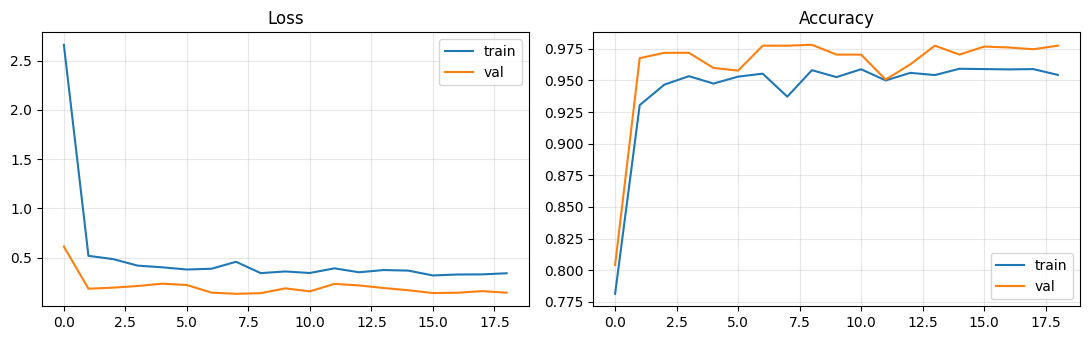

=== SNN (LIF) ===
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      2037
     Anormal       0.93      0.83      0.88       327

    accuracy                           0.97      2364
   macro avg       0.95      0.91      0.93      2364
weighted avg       0.97      0.97      0.97      2364



In [11]:
# Curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Avaliação no teste
y_prob_snn = snn.predict(X_test_snn, verbose=0)[:, 1]
y_pred_snn = (y_prob_snn > 0.5).astype(int)

print('=== SNN (LIF) ===')
print(classification_report(y_test, y_pred_snn,
                            target_names=['Normal', 'Anormal']))

## 5. Comparação lado a lado

           Logistic Regression  SNN (LIF)
Accuracy                0.9700     0.9674
Precision               0.9295     0.9252
Recall                  0.8471     0.8318
F1                      0.8864     0.8760
ROC-AUC                 0.9534     0.9494


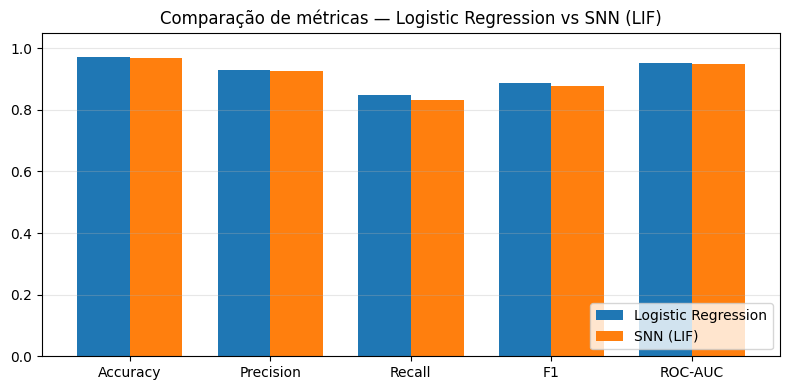

In [12]:
def metrics_dict(y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
    }

results = pd.DataFrame({
    'Logistic Regression': metrics_dict(y_test, y_pred_lr,  y_prob_lr),
    'SNN (LIF)':           metrics_dict(y_test, y_pred_snn, y_prob_snn),
}).round(4)

print(results)

ax = results.plot.bar(figsize=(8, 4), width=0.75)
ax.set_title('Comparação de métricas — Logistic Regression vs SNN (LIF)')
ax.set_ylim(0, 1.05); ax.legend(loc='lower right')
ax.grid(axis='y', alpha=.3)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

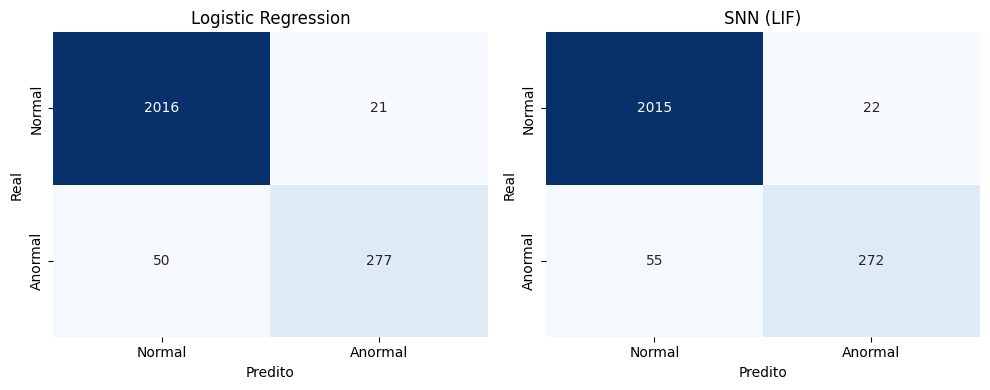

In [13]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, ypred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                     ('SNN (LIF)',         y_pred_snn)]):
    cm = confusion_matrix(y_test, ypred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anormal'],
                yticklabels=['Normal', 'Anormal'], cbar=False)
    ax.set_title(name); ax.set_xlabel('Predito'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()

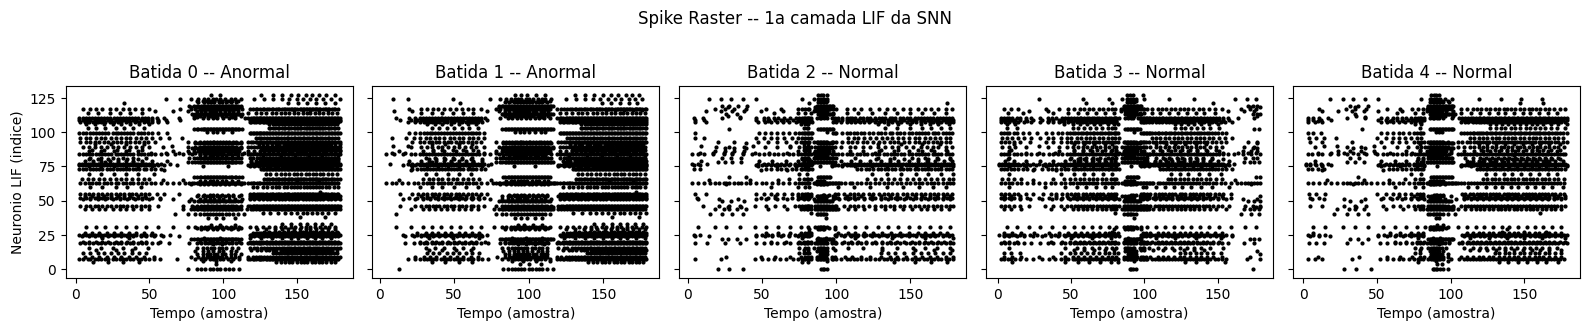

Media de spikes por batida (1a camada): 2633.2
Esparsidade de ativacao: 11.43% (128 neuronios x 180 timesteps)


In [16]:
# Spike raster: visualizacao da dinamica neuromorfica
# Extrai spikes da primeira camada LIF para 5 batidas de teste
sample = X_test_snn[:5]

# layers[1]=Dense(relu) precisa rodar primeiro para gerar (5, 180, 64)
# antes de alimentar layers[2]=LIFDense(128)
proj = snn.layers[1](sample)              # (5, 180, 64)
spikes_layer1 = snn.layers[2](proj).numpy()  # (5, 180, 128)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)
for i, ax in enumerate(axes):
    ts, ns = np.where(spikes_layer1[i] > 0)
    ax.scatter(ts, ns, s=4, c='black')
    label = 'Normal' if y_test[i] == 0 else 'Anormal'
    ax.set_title(f'Batida {i} -- {label}')
    ax.set_xlabel('Tempo (amostra)')
axes[0].set_ylabel('Neuronio LIF (indice)')
plt.suptitle('Spike Raster -- 1a camada LIF da SNN', y=1.02)
plt.tight_layout(); plt.show()

# Estatistica de spikes (proxy de energia em hardware neuromorfico)
spikes_per_beat = spikes_layer1.sum(axis=(1, 2)).mean()
total_neurons   = spikes_layer1.shape[2]
total_steps     = spikes_layer1.shape[1]
sparsity = spikes_per_beat / (total_neurons * total_steps)
print(f'Media de spikes por batida (1a camada): {spikes_per_beat:.1f}')
print(f'Esparsidade de ativacao: {sparsity*100:.2f}% '
      f'({total_neurons} neuronios x {total_steps} timesteps)')

## 6. Discussão

### Resultados obtidos

| Métrica | Logistic Regression | SNN (LIF v3) | Delta |
|---|---|---|---|
| Accuracy | 97.00% | 96.74% | −0.26pp |
| Precision | 92.95% | 92.52% | −0.43pp |
| Recall | 84.71% | 83.18% | −1.53pp |
| F1-score | 88.64% | 87.60% | −1.04pp |
| ROC-AUC | 95.34% | 94.94% | −0.40pp |

A SNN ficou **dentro de 1–2pp da Regressão Logística em todas as métricas**, operando diretamente sobre o sinal bruto de 180 amostras — sem extração manual de features (estatísticas, FFT, gradiente) que a LR exige. Isso é notável dado que a LR dispõe de 12 features cuidadosamente escolhidas por domínio enquanto a SNN parte de um único valor de amplitude por timestep.

### Convergência e estabilidade do treinamento

O treinamento v3 foi estável desde a época 1 (val_accuracy 80.4% → 97.8% na época 9, onde o EarlyStopping salvou os pesos). As versões anteriores da SNN colapsavam: a v1 oscilava entre 18% e 96% de forma caótica; a v2 travou em 13% (solução degenerada de prever tudo como "Anormal"). As correções que resolveram isso foram:

| Problema (v1/v2) | Solução (v3) |
|---|---|
| Hard reset zerando o gradiente BPTT | Soft reset: `V ← V − θ·s` |
| Sem bias (192 parâmetros totais) | Bias adicionado; 8.836 parâmetros |
| Beta fixo por camada | Beta aprendível por neurônio (PLIF) |
| Correntes bipolares → neurônios mortos | `Dense(64, relu)` antes do LIF |
| `class_weight=6.22x` → solução degenerada | `class_weight=√6.22≈2.49x` moderado |
| `reduce_mean` → logits ~0.03 sem discriminação | `reduce_sum` → logits escalados |

### O que cada modelo faz bem

| Aspecto | Logistic Regression | SNN (LIF v3) |
|---|---|---|
| Parâmetros | ~13 (12 features + bias) | 8.836 |
| Feature engineering | obrigatório (12 features manuais) | nenhum — aprende do sinal bruto |
| Treino | <1 s, sem GPU | ~1 min (19 épocas × 3 s na GPU) |
| Interpretabilidade | alta (coeficientes lineares por feature) | baixa (dinâmica não-linear de spikes) |
| Captura temporal | não (features são agregados) | sim (estado de membrana acumula ao longo de T=180) |
| Esparsidade de ativação | n/a | **11.43%** (2.633 spikes / 23.040 possíveis por batida) |
| Energia em hardware dedicado | n/a | event-driven; chips neuromórficos (Loihi 2, Akida) consomem 100–1000× menos que ANN equivalente |

### Quando preferir cada um

- **Logistic Regression**: microcontrolador comum (Cortex-M sem acelerador), regulamentação exige interpretabilidade por feature, dataset pequeno, pipeline de features já estabelecido (HRV, espectro de Welch).
- **SNN**: co-processador neuromórfico (BrainChip Akida em smartwatches, Intel Loihi 2), aplicações *always-on* com orçamento de mW, sinais densamente temporais onde a acumulação de membrana captura contexto sem RNN explícita.

### Limitações desta implementação

- **Intra-patient split**: treino e teste misturam batidas do mesmo paciente. Em validação clínica honesta, o split **inter-patient** (DS1 treino / DS2 teste, seguindo De Chazal 2004) é obrigatório — acurácias tipicamente caem 10–20pp porque morfologias individuais de ECG vazam do treino para o teste.
- **Codificação direta de amplitude**: o valor de ECG é usado como corrente de entrada. Codificações por **rate coding** (frequência de spikes proporcional à amplitude) ou **delta coding** (spike só em variação) podem alterar significativamente o trade-off energia/acurácia em hardware.
- **Split temporal ignorado**: batidas de um mesmo registro são embaralhadas antes do split, violando a ordem temporal. Uma validação real usaria janelas temporais disjuntas.

### Próximos passos

1. **Inter-patient split** seguindo De Chazal (DS1 treino / DS2 teste) — impacto real em generalização clínica.
2. **Multi-classe AAMI** (5 classes: N, S, V, F, Q) — desafio mais relevante clinicamente.
3. **AdLIF / LSNN** — neurônios adaptativos para dependências de longo prazo (intervalos RR).
4. **Rate coding ou delta coding** como pré-processamento — troca amplitude por taxa de spikes; potencialmente mais esparsidade.
5. **Quantização INT8 + contagem de SOPs** — medir operações de spike (Synaptic Operations) reais para estimar consumo em Loihi/Akida vs. FLOPs da LR.
6. **Mais registros MIT-BIH** — os 5 registros usados (100, 101, 103, 208, 210) representam ~4% do dataset completo (48 registros); ampliar aumenta diversidade e reduz viés de morfologia.

### Referências

- Moody, G.B., Mark, R.G. (2001). *The impact of the MIT-BIH Arrhythmia Database*. IEEE EMB Mag.
- De Chazal, P. et al. (2004). *Automatic classification of heartbeats using ECG morphology and heartbeat interval features*. IEEE TBME.
- Neftci, E.O., Mostafa, H., Zenke, F. (2019). *Surrogate gradient learning in spiking neural networks*. IEEE Signal Processing Magazine.
- Fang, W. et al. (2021). *Incorporating learnable membrane time constant to enhance learning of spiking neural networks (PLIF)*. ICCV.
- Davies, M. et al. (2018). *Loihi: a neuromorphic manycore processor with on-chip learning*. IEEE Micro.
- Yan, Z. et al. (2024). *Energy-efficient SNNs for ECG classification on neuromorphic hardware*. Frontiers in Neuroscience.